# **Predictive Modeling and Fairness in Health Insurance Pricing**

**Students** : Allizha Theiventhiram and Flaminia Trinca

---

This notebook examines whether smoking status is associated with higher insurance charges and whether a machine learning model predicts these charges in a fair manner.

Using a synthetic but realistic [U.S. health insurance dataset](https://www.kaggle.com/datasets/sridharstreaks/insurance-data-for-machine-learning/data)  from Kaggle, we study both the **descriptive cost differences** between smokers and non-smokers and the **fairness of predictive models** trained on this data.

---

## Research questions

**Q1 (Descriptive).**  
Do smokers incur higher annual insurance charges than non-smokers in the dataset?

**Q2 (Fairness audit).**  
Does a predictive model reproduce these cost differences **without introducing additional unfairness**, such as systematic mispricing or unequal prediction errors between groups?

To address these questions, we combine predictive modeling with a multi-view fairness evaluation.

---

## Notebook structure

1. **Data preparation and exploratory analysis**  
   Clean and preprocess the data, encode categorical variables, and analyze charge distributions to establish whether smokers and non-smokers differ in true medical costs.

2. **Predictive modeling**  
   Train and compare several regression models and select a strong baseline model based on predictive performance.

3. **Fairness analysis (smokers vs non-smokers)**  
   Evaluate fairness using residual-based metrics, bootstrap confidence intervals for group differences, and classification-style fairness metrics adapted from the course. A stress test is also performed by injecting a known unfair surcharge.

4. **Discussion and conclusions**  
   Interpret results, discuss limitations, and summarize implications for fairness in insurance pricing.

---

## Summary

This notebook provides:
- a complete predictive analysis of insurance charges,
- a rigorous fairness assessment between smokers and non-smokers,
- and a clear conclusion to the research questions :

While smokers incur higher true insurance costs in the data, the predictive model captures these differences without introducing additional unfair bias between smokers and non-smokers.

### **Imports**

In [ ]:
from __future__ import annotations

# --- Standard library ---
import random
import time
import warnings

# --- Data / numerics ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# --- Scikit-learn: utilities ---
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Scikit-learn: models ---
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# --- Scikit-learn: metrics ---
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# --- Statsmodels (GLM) ---
import statsmodels.api as sm

# --- Graphviz (DAG) ---
from graphviz import Digraph

# Silence pandas FutureWarnings for cleaner outputs
warnings.filterwarnings("ignore", category=FutureWarning)

# **Part 1 — Data Preparation & Exploration**

We begin by loading the dataset and performing basic data cleaning.

The dataset contains information related to health insurance pricing, including:

- demographic factors (age, gender, region)  
- lifestyle indicators (BMI, exercise frequency, smoking status)  
- medical history (personal and family conditions)  
- insurance plan characteristics (coverage level)  
- annual **charges**, which serve as the target variable  

The objectives of this section are to:

- ensure consistent and meaningful variable types,  
- handle missing values in a principled manner,  
- encode categorical variables for modeling,  
- explore correlations and distributional patterns in the data, and  
- identify real-world group differences *prior to model training*.  

## 1.1 Data Loading and Initial Cleaning

We begin by loading the raw dataset and applying basic preprocessing steps to ensure consistency and reliability.

The following operations are performed:

- load the dataset from a CSV file,
- standardize column names (lowercase, underscores instead of spaces),
- enforce appropriate data types for numerical and categorical variables,
- identify and summarize missing values,
- inspect basic statistics of the target variable (*charges*).

These steps ensure that the dataset is in a clean and well-defined state before feature encoding, modeling, and fairness analysis.

In [ ]:
# ============================================================
# 1.1 Data Loading and Initial Cleaning
# ============================================================

# Load dataset
DATAFILE = "insurance.csv"
df = pd.read_csv(DATAFILE)

# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# Display basic information
print("Dataset shape:", df.shape)
display(df.head())

# Separate numerical and categorical candidates
num_candidates = ["age", "bmi", "children", "charges"]
cat_candidates = [
    "gender",
    "smoker",
    "region",
    "medical_history",
    "family_medical_history",
    "exercise_frequency",
    "occupation",
    "coverage_level",
]

# Enforce numeric types
for col in num_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Enforce categorical types
for col in cat_candidates:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Missingness summary
missing_rate = df.isna().mean().sort_values(ascending=False)
display(pd.DataFrame({"Missing rate": missing_rate.round(3)}))

# Basic statistics for target variable
print("Charges summary:")
print(f"Min: {df['charges'].min():.2f}")
print(f"Max: {df['charges'].max():.2f}")
print(f"Mean: {df['charges'].mean():.2f}")
print(f"Median: {df['charges'].median():.2f}")

Dataset shape: (1000000, 12)


,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges
0,46,male,21.45,5,yes,southeast,Diabetes,NaN,Never,Blue collar,Premium,20460.307669
1,25,female,25.38,2,yes,northwest,Diabetes,High blood pressure,Occasionally,White collar,Premium,20390.899218
2,38,male,44.88,2,yes,southwest,NaN,High blood pressure,Occasionally,Blue collar,Premium,20204.476302
3,25,male,19.89,0,no,northwest,NaN,Diabetes,Rarely,White collar,Standard,11789.029843
4,49,male,38.21,3,yes,northwest,Diabetes,High blood pressure,Rarely,White collar,Standard,19268.309838


,Missing rate
medical_history,0.251
family_medical_history,0.250
age,0.000
gender,0.000
children,0.000
bmi,0.000
region,0.000
smoker,0.000
exercise_frequency,0.000
occupation,0.000


Charges summary:
Min: 3445.01
Max: 32561.56
Mean: 16735.12
Median: 16622.13


## 1.2 Handling Missing Values

Two categorical variables contain missing values:

- `medical_history`  
- `family_medical_history`  

In this dataset, missing entries likely indicate the absence of a recorded medical condition rather than unknown information. Instead of applying statistical imputation, we introduce an explicit category, **“No Record”**, to represent this case.

This approach preserves potentially meaningful information, avoids mixing missingness with observed conditions, and ensures consistent group comparisons during the subsequent fairness analysis.

In [ ]:
# ============================================================
# 1.2 Handling Missing Values
# ============================================================

# A) Medical history columns: treat missing as an explicit category
for col in ["medical_history", "family_medical_history"]:
    if col in df.columns:
        # ensure "No Record" exists as a category
        if "No Record" not in df[col].cat.categories:
            df[col] = df[col].cat.add_categories(["No Record"])
        # fill missing with that category
        df[col] = df[col].fillna("No Record")

# B) Numeric columns: if coercion created missing values, impute with the median
for col in ["age", "bmi", "children", "charges"]:
    if col in df.columns and df[col].isna().any():
        n_missing = int(df[col].isna().sum())
        median_val = df[col].median()
        print(f"Filling {n_missing} missing values in '{col}' with median = {median_val:.3f}")
        df[col] = df[col].fillna(median_val)

# Quick check
missing_rate_after = df.isna().mean().sort_values(ascending=False)
display(pd.DataFrame({"Missing rate (after)": missing_rate_after.round(3)}))

display(df.head())

,Missing rate (after)
age,0.0
gender,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
medical_history,0.0
family_medical_history,0.0
exercise_frequency,0.0
occupation,0.0


,age,gender,bmi,children,smoker,region,medical_history,family_medical_history,exercise_frequency,occupation,coverage_level,charges
0,46,male,21.45,5,yes,southeast,Diabetes,No Record,Never,Blue collar,Premium,20460.307669
1,25,female,25.38,2,yes,northwest,Diabetes,High blood pressure,Occasionally,White collar,Premium,20390.899218
2,38,male,44.88,2,yes,southwest,No Record,High blood pressure,Occasionally,Blue collar,Premium,20204.476302
3,25,male,19.89,0,no,northwest,No Record,Diabetes,Rarely,White collar,Standard,11789.029843
4,49,male,38.21,3,yes,northwest,Diabetes,High blood pressure,Rarely,White collar,Standard,19268.309838


## 1.3 Encoding and Feature Construction

To prepare the data for modeling, we encode all categorical variables using one-hot encoding. Since all categorical features have a small number of levels, this transformation is appropriate and preserves interpretability.

We apply one-hot encoding with the first category dropped in each case in order to avoid perfect multicollinearity in linear models. This results in binary indicator variables such as `smoker_yes`, which are later used explicitly in the fairness analysis.

Finally, we construct the feature matrix \(X\) and the target vector \(y\), where the target corresponds to annual insurance charges.

In [ ]:
# ============================================================
# 1.3 Encoding and Feature Construction
# ============================================================

# Select categorical columns (excluding the target)
cat_cols = [c for c in df.select_dtypes(include="category").columns if c != "charges"]

# One-hot encode categorical variables
df_enc = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Define features and target
X = df_enc.drop(columns=["charges"])
y = df_enc["charges"]

print(f"Encoded {len(cat_cols)} categorical columns → {X.shape[1]} total features.")
display(df_enc.head())

Encoded 8 categorical columns → 22 total features.


,age,bmi,children,charges,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest,medical_history_Heart disease,...,family_medical_history_High blood pressure,family_medical_history_No Record,exercise_frequency_Never,exercise_frequency_Occasionally,exercise_frequency_Rarely,occupation_Student,occupation_Unemployed,occupation_White collar,coverage_level_Premium,coverage_level_Standard
0,46,21.45,5,20460.307669,1,1,0,1,0,0,...,0,1,1,0,0,0,0,0,1,0
1,25,25.38,2,20390.899218,0,1,1,0,0,0,...,1,0,0,1,0,0,0,1,1,0
2,38,44.88,2,20204.476302,1,1,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
3,25,19.89,0,11789.029843,1,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,1
4,49,38.21,3,19268.309838,1,1,1,0,0,0,...,1,0,0,0,1,0,0,1,0,1


## 1.4 Exploratory Analysis: Verifying Group Differences

Before training any predictive model, we examine whether the dataset itself exhibits systematic cost differences between smokers and non-smokers.

This step is essential for fairness analysis: a model is not unfair if it reflects real, data-driven differences in medical costs. Fairness concerns arise only if the model introduces additional disparities beyond those present in the underlying data.

We begin with correlation analysis to identify features that are strongly associated with insurance charges.

### 1.4.1 Correlation Analysis

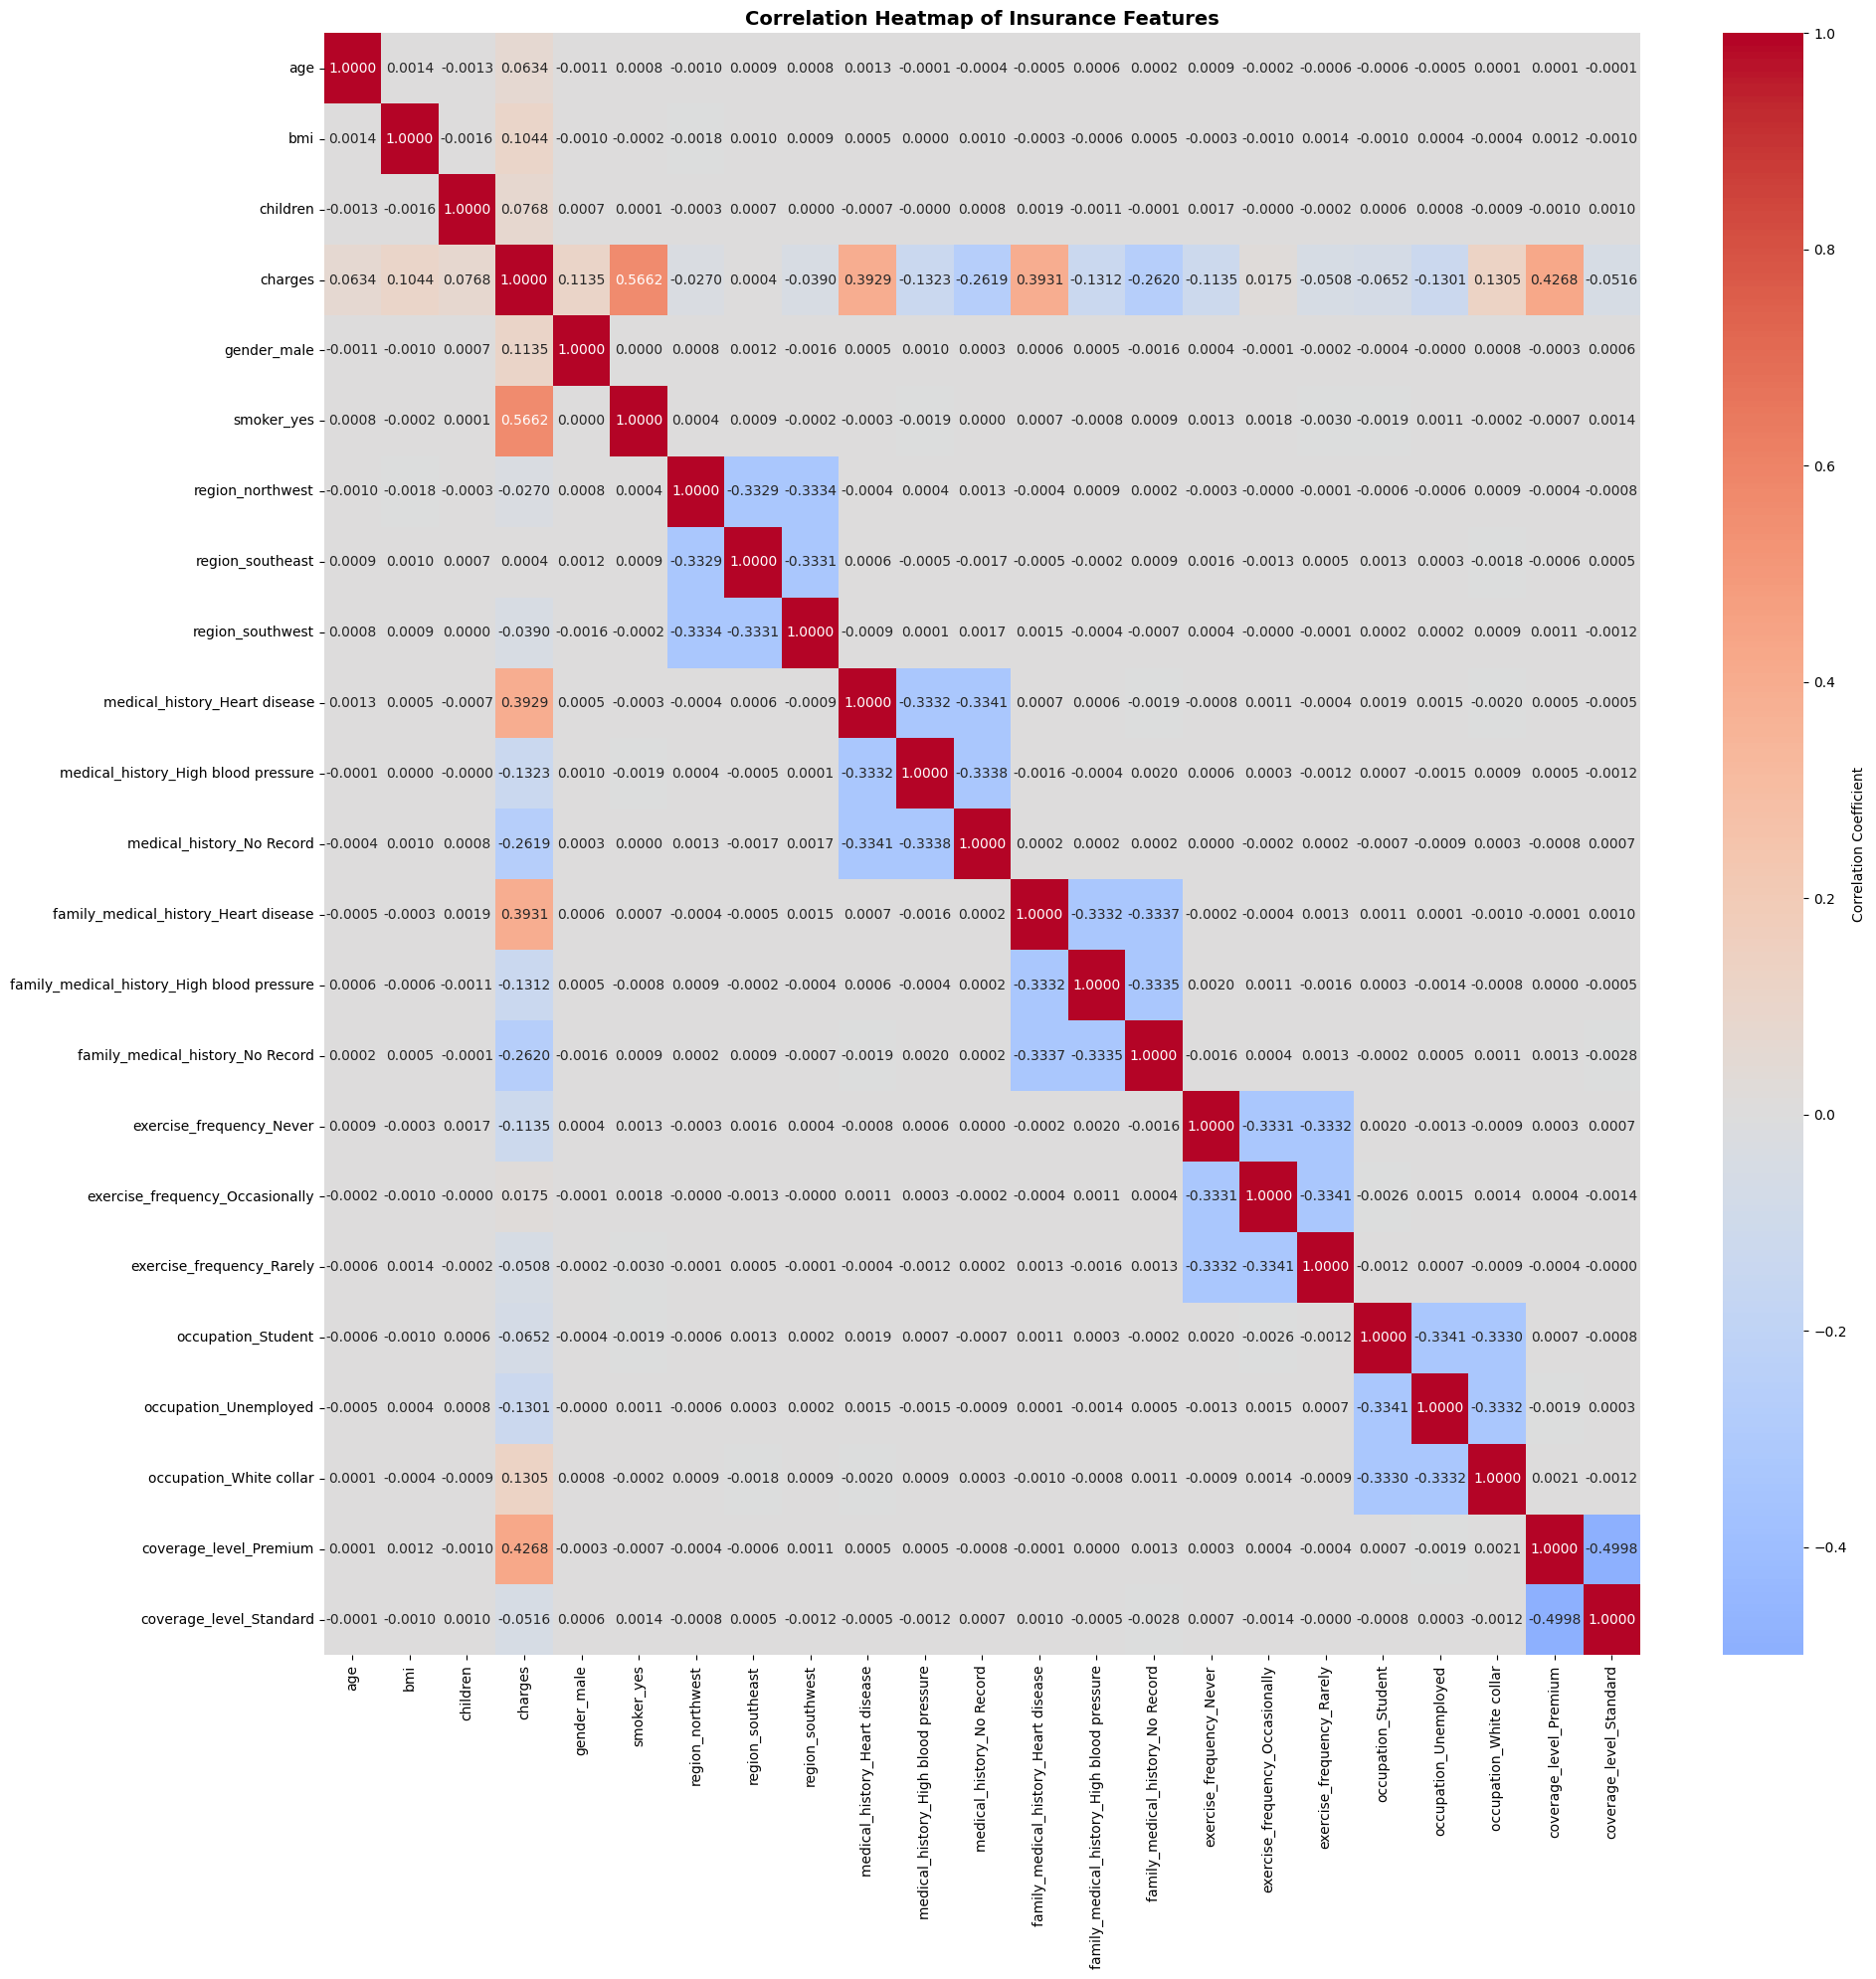

In [ ]:
# ============================================================
# 1.4.1 Correlation Analysis
# ============================================================

# Compute correlation matrix
corr = df_enc.corr(numeric_only=True)

# Visualize correlations using a heatmap
plt.figure(figsize=(20,20))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".4f",
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title("Correlation Heatmap of Insurance Features", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**Interpretation.**  
The correlation heatmap highlights several variables that are associated with insurance charges. Notably, the indicator for smoking status (`smoker_yes`) exhibits one of the highest positive correlations with the target variable. This confirms that smoking is a major cost-driving factor in the dataset itself, rather than an artifact of modeling.

This observation justifies the choice of smoking status as the sensitive attribute for our fairness analysis. We therefore focus next on the direct correlations between individual features and insurance charges to clearly identify the most influential predictors.

### 1.4.2 Key Correlations with Insurance Charges

### Key correlations with the target variable

We next examine the correlation between each encoded feature and the target variable, `charges`. This allows us to identify the strongest cost drivers in the data and to verify whether smoking status is already associated with higher insurance costs prior to modeling.

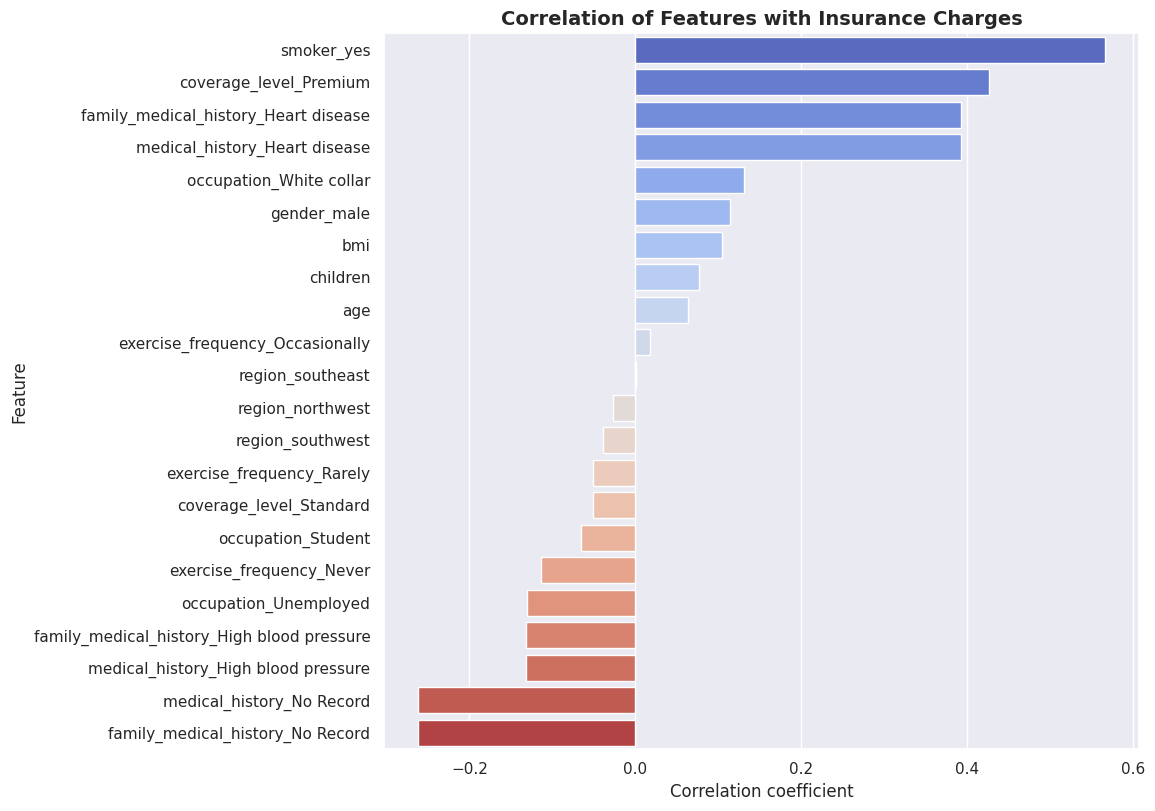

In [ ]:
# Correlation with target variable
corr_with_target = (
    corr["charges"]
    .drop("charges")
    .sort_values(ascending=False)
)

# Plot feature correlations with charges
#plt.figure(figsize=(6, 8))
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette="coolwarm"
)

plt.title("Correlation of Features with Insurance Charges", fontsize=14, weight="bold")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpretation.**  

Smoking status exhibits the strongest positive correlation with charges, followed by
premium coverage level and medical history indicators. Lifestyle and demographic variables
such as BMI and age show moderate influence, while region and occupation contribute
minimally.  

This confirms that smoking is a genuine cost-driving factor present in the data itself,
rather than an artifact of the predictive model.

Correlation analysis highlights smoking as a key cost driver, but fairness assessment
requires understanding group-level cost distributions.
We therefore compare the full distribution of insurance charges for smokers and non-smokers.

### 1.4.3 Distribution of Charges by Smoking Status

### Distribution of insurance charges by smoking status

To further examine group differences, we compare the distribution of annual insurance charges for smokers and non-smokers.

If the dataset reflects realistic medical risk, we expect smokers to exhibit higher average costs, greater variability, and a heavier upper tail. Establishing this pattern is crucial: predicting higher costs for smokers is not unfair if such differences are already present in the data.

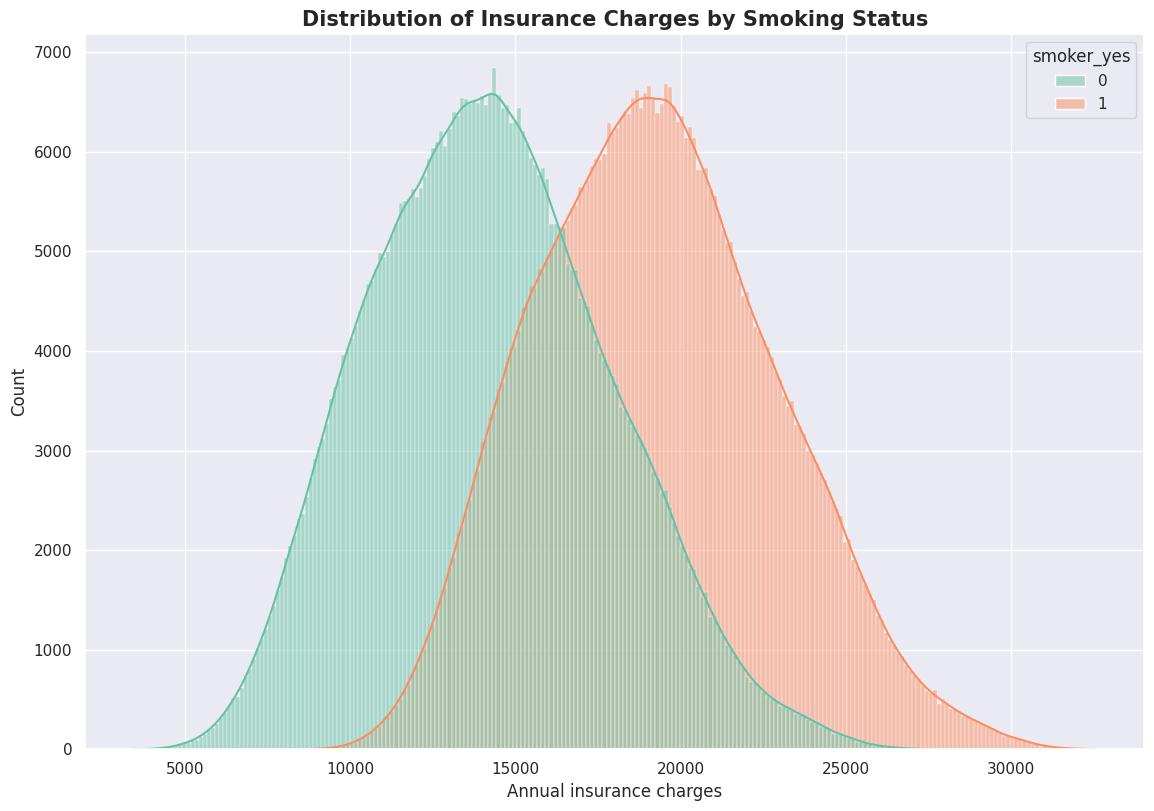

In [ ]:
# Distribution of charges by smoking status
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.histplot(
    data=df_enc,
    x="charges",
    hue="smoker_yes",
    kde=True,
    palette="Set2"
)

plt.title("Distribution of Insurance Charges by Smoking Status", fontsize=15, weight="bold")
plt.xlabel("Annual insurance charges")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation.**

These distributions highlight an important fairness principle:
higher predicted costs for smokers are not, by themselves, evidence of unfairness,
provided that smokers genuinely incur higher medical costs in the underlying data.

## 1.5 Train–Test Split

We split the dataset into training and test sets to evaluate model generalization on unseen data.

The training set is used to fit the predictive models, while the test set is reserved for performance evaluation and all subsequent fairness analyses. This separation mirrors real-world deployment, where models trained on historical data are applied to new individuals.

We use a 75% / 25% split with a fixed random seed to ensure reproducibility.

In [ ]:
# ============================================================
# 1.5 Train–Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (750000, 22)
Test shape : (250000, 22)


## 1.6 Causal and Conceptual Diagram of Insurance Charges (DAG)

To complement the exploratory correlation analysis, we introduce a conceptual causal diagram (Directed Acyclic Graph, DAG) describing the assumed data-generating process for insurance charges.

The DAG summarizes domain-informed assumptions about how demographic, lifestyle, health, and insurance-related variables influence medical costs. While the dataset is observational, making causal identification impossible, explicitly stating these assumptions helps interpret both model behavior and fairness results.

The DAG serves three main purposes:

1. **Clarifying causal structure**  
   Some variables, such as smoking status, medical history, and insurance coverage level, are assumed to have direct effects on insurance charges. Other variables, such as age or exercise frequency, influence charges indirectly through intermediate factors like BMI or health conditions.

2. **Connecting domain knowledge and modeling**  
   The diagram reflects well-established medical and actuarial relationships, for example:
   - smoking increases health risks and medical costs,
   - BMI and exercise affect medical history,
   - occupation influences insurance coverage choices.

3. **Supporting fairness interpretation**  
   Fairness conclusions depend on causal assumptions. If smoking has a genuine causal effect on medical costs, then differences in predicted charges between smokers and non-smokers may be justified. In contrast, variables with weak or indirect links (e.g., region) could raise fairness concerns if amplified by a model.

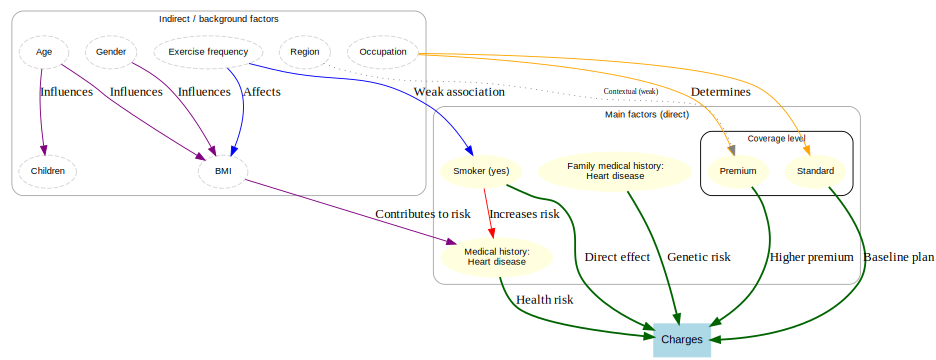

In [ ]:
# ============================================================
# 1.6 Causal and Conceptual Diagram of Insurance Charges (DAG)
# ============================================================

# Create a directed acyclic graph (DAG) representing insurance pricing mechanisms
dot = Digraph('Insurance Charges')
dot.attr(rankdir='TB', size='13')  # Top-to-bottom layout for readability

# ============================================================
# Target variable: Insurance charges
# ============================================================
dot.attr(
    'node',
    shape='box',
    style='filled',
    color='lightblue',
    fontname='Helvetica',
    fontsize='12'
)
dot.node('C', 'Charges')

# ============================================================
# Main explanatory variables with direct influence on charges
# ============================================================
dot.attr(
    'node',
    shape='ellipse',
    style='filled',
    color='lightyellow',
    fontname='Helvetica',
    fontsize='10'
)

dot.node('SM', 'Smoker (yes)')
dot.node('MH', 'Medical history:\nHeart disease')
dot.node('FH', 'Family medical history:\nHeart disease')

# Insurance coverage levels (direct pricing effect)
dot.node('CLP', 'Premium')
dot.node('CLS', 'Standard')

# ============================================================
# Indirect and background variables
# ============================================================
dot.attr(
    'node',
    shape='ellipse',
    style='dashed',
    color='lightgray',
    fontname='Helvetica',
    fontsize='10'
)

dot.node('BMI', 'BMI')
dot.node('AGE', 'Age')
dot.node('GEN', 'Gender')
dot.node('CH', 'Children')
dot.node('EX', 'Exercise frequency')
dot.node('OCC', 'Occupation')
dot.node('REG', 'Region')

# ============================================================
# Variable groupings (clusters) for conceptual clarity
# ============================================================

# Indirect / background factors cluster
with dot.subgraph(name='cluster_indirect') as c:
    c.attr(
        label='Indirect / background factors',
        style='rounded',
        color='darkgray',
        fontname='Helvetica',
        fontsize='10'
    )
    c.node('BMI')
    c.node('AGE')
    c.node('GEN')
    c.node('CH')
    c.node('EX')
    c.node('OCC')
    c.node('REG')

# Direct factors cluster
with dot.subgraph(name='cluster_factors') as c:
    c.attr(
        label='Main factors (direct)',
        style='rounded',
        color='darkgray',
        fontname='Helvetica',
        fontsize='10'
    )

    c.node('SM')
    c.node('MH')
    c.node('FH')

    # Coverage level sub-cluster
    with c.subgraph(name='cluster_coverage') as cc:
        cc.attr(
            label='Coverage level',
            style='rounded',
            color='black',
            fontname='Helvetica',
            fontsize='9'
        )
        cc.node('CLP')
        cc.node('CLS')

# ============================================================
# Direct causal effects on insurance charges
# ============================================================
dot.edge('SM',  'C', color='darkgreen', penwidth='2', label='Direct effect')
dot.edge('MH',  'C', color='darkgreen', penwidth='2', label='Health risk')
dot.edge('FH',  'C', color='darkgreen', penwidth='2', label='Genetic risk')
dot.edge('CLP', 'C', color='darkgreen', penwidth='2', label='Higher premium')
dot.edge('CLS', 'C', color='darkgreen', penwidth='2', label='Baseline plan')

# ============================================================
# Indirect relationships and mediating pathways
# ============================================================

# Demographic influences
dot.edge('AGE', 'BMI', color='purple', label='Influences')
dot.edge('GEN', 'BMI', color='purple', label='Influences')
dot.edge('AGE', 'CH',  color='purple', label='Influences')

# Lifestyle effects
dot.edge('EX', 'BMI', color='blue', label='Affects')
dot.edge('EX', 'SM',  color='blue', label='Weak association')

# Health risk pathways
dot.edge('SM',  'MH', color='red', label='Increases risk')
dot.edge('BMI', 'MH', color='purple', label='Contributes to risk')

# Socioeconomic context
dot.edge('OCC', 'CLP', color='orange', label='Determines')
dot.edge('OCC', 'CLS', color='orange')

# Weak contextual effects
dot.edge(
    'REG', 'CLP',
    color='gray',
    style='dotted',
    label='Contextual (weak)',
    fontsize='8'
)

# ============================================================
# Render and display the DAG
# ============================================================
dot.render('insurance_dag', format='png', cleanup=True)
dot

**Interpretation of the DAG**

The diagram distinguishes between three types of variables:

**Direct factors.**  
Smoking status, medical history, family medical history, and insurance coverage level are assumed to have direct effects on insurance charges. These variables represent primary drivers of medical risk and pricing.

**Indirect or background factors.**  
Variables such as age, gender, exercise frequency, BMI, occupation, and region influence charges indirectly. For example, age and exercise affect BMI, which in turn contributes to medical history, while occupation and region influence the choice of insurance coverage.

**Contextual variables.**  
Some factors (e.g., region) are assumed to have weak or contextual effects. If amplified by a predictive model, such variables could raise fairness concerns.

**Why the DAG matters for fairness**

The DAG plays a key role in the fairness analysis. Because smoking status is assumed to have a genuine causal effect on health risk and medical costs, differences in predicted charges between smokers and non-smokers are not inherently unfair.

Fairness concerns arise instead if a model introduces additional disparities that are not supported by these causal pathways, such as systematically larger errors or unjustified surcharges for one group. This causal perspective motivates our focus on error-based and outcome-conditional fairness metrics, rather than enforcing equal predicted outcomes across groups.

# Part 2 — Predictive Modeling

In this part, we train and compare several regression models to predict annual insurance charges.

Our goals are to:
- identify which model best predicts medical costs,
- compare linear and non-linear approaches,
- select a strong and stable baseline model for the fairness analysis.

All models are evaluated on the same train–test split using standard regression metrics.

## 2.1 Model Training and Test-Set Evaluation

We train several regression models to predict annual insurance charges and compare their performance on a held-out test set.  
The goal of this step is to identify a strong and stable baseline model that will later be audited for fairness.

### Models evaluated
- Linear Regression  
- Elastic Net (with cross-validated regularization)  
- HistGradientBoosting Regressor  
- Multilayer Perceptron (MLP) Regressor  
- Generalized Linear Model (Gamma with log link)

### Evaluation metrics
Model performance is evaluated on the test set using:
- **R²**: proportion of variance explained by the model  
- **MAE**: mean absolute error (in CHF), directly interpretable for pricing  
- **RMSE**: root mean squared error, which penalizes large prediction errors  

These metrics jointly assess predictive accuracy, robustness, and suitability for fairness analysis.

### Model comparison and selection
All models are trained on the same training set and evaluated on the same test set to ensure a fair comparison.  
The model with the lowest test-set RMSE is selected as the baseline model for the subsequent fairness analysis. We select the best model based on RMSE because it penalizes large pricing errors, is directly interpretable in currency units, and is well aligned with both insurance risk considerations and subsequent fairness analysis.

In [ ]:
# ============================================================
# 2.1 Model Training and Test-Set Evaluation
# ============================================================

def evaluate_regression(y_true, y_pred):
    """Return standard regression metrics."""
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
    }

results = {}
predictions = {}
timings = {}

# ============================================================
# A) Linear Regression
# ============================================================
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

start = time.time()
lin_pipe.fit(X_train, y_train)
y_pred_lin = lin_pipe.predict(X_test)
timings["Linear Regression"] = time.time() - start

results["Linear Regression"] = evaluate_regression(y_test, y_pred_lin)
predictions["Linear Regression"] = y_pred_lin

# ============================================================
# B) Elastic Net (CV)
# ============================================================
enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-3, 2, 25),
        cv=5,
        max_iter=10000,
        random_state=RANDOM_STATE,
    )),
])

start = time.time()
enet_pipe.fit(X_train, y_train)
y_pred_enet = enet_pipe.predict(X_test)
timings["Elastic Net"] = time.time() - start

results["Elastic Net"] = evaluate_regression(y_test, y_pred_enet)
predictions["Elastic Net"] = y_pred_enet

# ============================================================
# C) HistGradientBoosting
# ============================================================
hgb = HistGradientBoostingRegressor(random_state=RANDOM_STATE)

start = time.time()
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)
timings["HistGradientBoosting"] = time.time() - start

results["HistGradientBoosting"] = evaluate_regression(y_test, y_pred_hgb)
predictions["HistGradientBoosting"] = y_pred_hgb

# ============================================================
# D) MLP Regressor
# ============================================================
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )),
])

start = time.time()
mlp_pipe.fit(X_train, y_train)
y_pred_mlp = mlp_pipe.predict(X_test)
timings["MLP"] = time.time() - start

results["MLP"] = evaluate_regression(y_test, y_pred_mlp)
predictions["MLP"] = y_pred_mlp

# ============================================================
# E) GLM (Gamma, log link)
# ============================================================
X_train_glm = sm.add_constant(X_train, has_constant="add")
X_test_glm  = sm.add_constant(X_test,  has_constant="add")

glm = sm.GLM(
    y_train,
    X_train_glm,
    family=sm.families.Gamma(sm.families.links.log()),
)

start = time.time()
glm_fit = glm.fit()
y_pred_glm = glm_fit.predict(X_test_glm)
timings["GLM (Gamma-log)"] = time.time() - start

results["GLM (Gamma-log)"] = evaluate_regression(y_test, y_pred_glm)
predictions["GLM (Gamma-log)"] = y_pred_glm

# ============================================================
# Summary table
# ============================================================
metrics_df = (
    pd.DataFrame(results)
      .T
      .assign(Time_s=lambda d: [round(timings[m], 2) for m in d.index])
      .round(3)
)

display(metrics_df.sort_values("RMSE"))

best_model = metrics_df["RMSE"].idxmin()
print(f"Best model by RMSE: {best_model}")

,R2,MAE,RMSE,Time_s
Linear Regression,0.996,250.291,288.892,1.05
Elastic Net,0.996,250.293,288.894,10.15
MLP,0.995,256.421,299.070,73.82
HistGradientBoosting,0.994,274.846,328.564,25.29
GLM (Gamma-log),0.957,622.795,911.947,15.63


Best model by RMSE: Linear Regression


**Result.**

Linear Regression and Elastic Net achieve the best test-set performance (highest R² and lowest errors), while more complex models (HGB, MLP) offer no meaningful improvement. We therefore use the best-performing linear model as the baseline for fairness analysis.

**2.1.1 Visual Comparison**


**RMSE of Machine Learning Models**

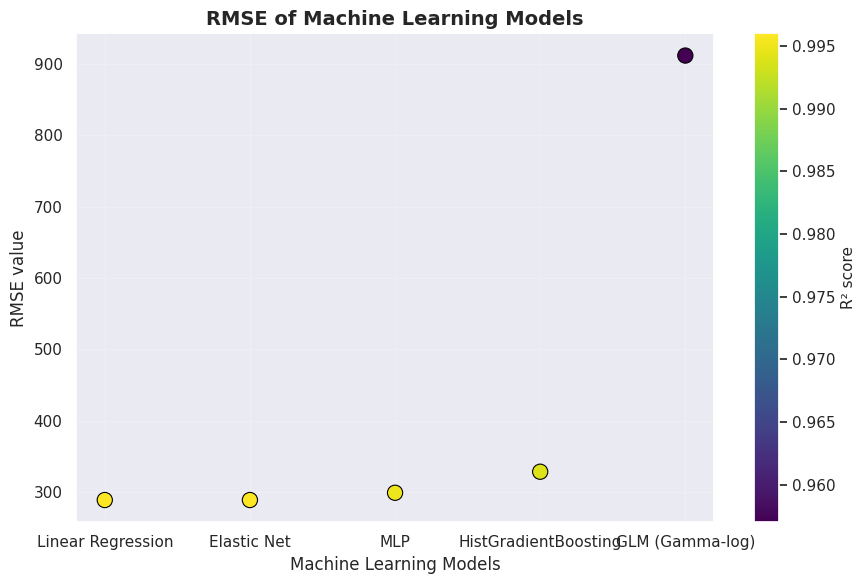

In [ ]:
# Sort models by RMSE (best to worst)
df_plot = metrics_df.sort_values("RMSE").copy()

plt.figure(figsize=(9,6))

# x positions = 0,1,2,... for each model
x_pos = range(len(df_plot))

# Scatter: y = RMSE, color = R²
sc = plt.scatter(
    x_pos,
    df_plot["RMSE"],
    c=df_plot["R2"],        # color encodes R²
    cmap="viridis",
    s=120,
    edgecolor="black",
    linewidth=0.8
)

# X-axis: model names
plt.xticks(x_pos, df_plot.index, fontsize=11)
plt.ylabel("RMSE value", fontsize=12)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.title("RMSE of Machine Learning Models", fontsize=14, weight="bold")

# Colorbar for R²
cbar = plt.colorbar(sc)
cbar.set_label("R² score", fontsize=11)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Interpretation.**

Each point is a model; lower RMSE is better. Color indicates R², confirming that the lowest-RMSE models also achieve the highest explained variance.

**Model Performance Comparison Across Metrics**

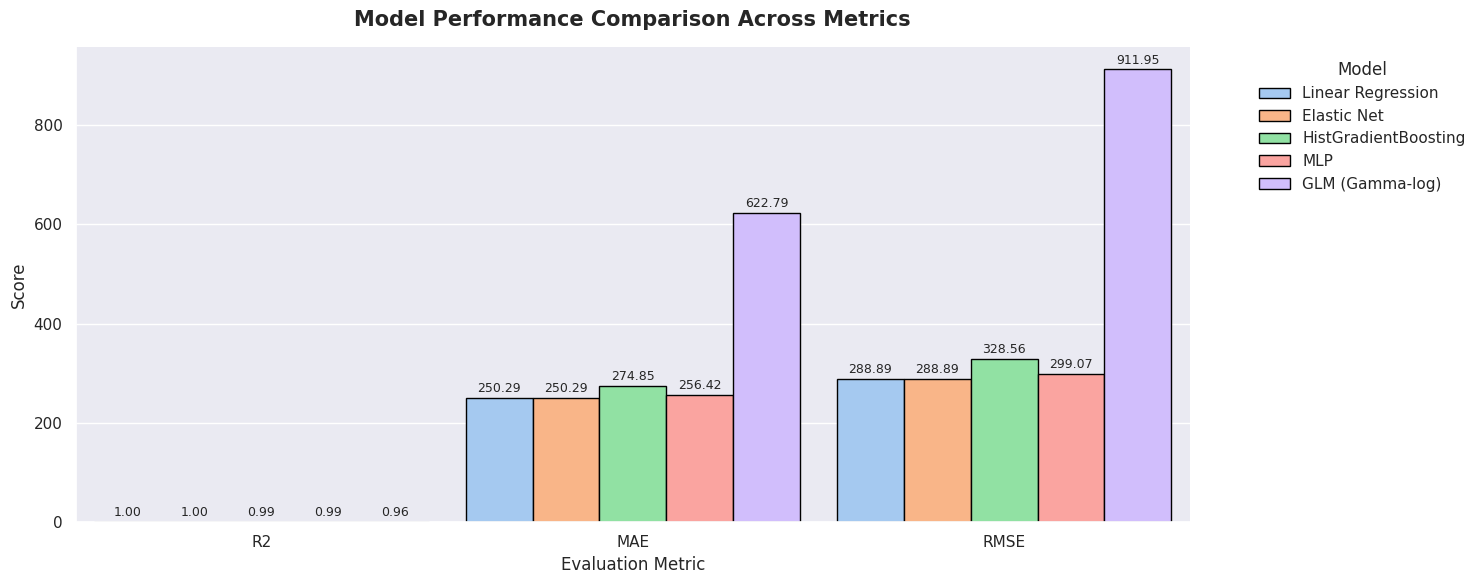

In [ ]:
# Model Performance Comparison

df_plot = (
    metrics_df.reset_index()
    .rename(columns={'index':'Model'})
    .melt(id_vars='Model', value_vars=['R2', 'MAE', 'RMSE'],
          var_name='Metric', value_name='Value')
)

plt.figure(figsize=(15,6))
sns.barplot(
    data=df_plot,
    x='Metric', y='Value', hue='Model',
    palette='pastel', edgecolor='black', saturation=0.9, width=0.9
)

# Add value labels (rounded to 2 decimals)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=2)

plt.title('Model Performance Comparison Across Metrics', fontsize=15, weight='bold', pad=15)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 2.2 Cross-validation: robustness check

Because test performance depends on one split, we also run 3-fold cross-validation to confirm that the model ranking is stable across different subsets of the data.

**Cross-Validation Code**

In [ ]:
# ============================================================
# Cross-Validation Performance Comparison
# ============================================================

# ============================================================
# Models evaluated
# ============================================================
cv_models = {
    "Linear Regression": LinearRegression(),
    "Elastic Net": ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-3, 2, 25),
        cv=3,
        max_iter=5000,
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE
    )
}

# ============================================================
# Helper: attach StandardScaler only when required
# ============================================================
def make_pipeline(model):
    """Attach StandardScaler only when needed."""
    if isinstance(model, (LinearRegression, ElasticNetCV, MLPRegressor)):
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    return model

# ============================================================
# Run cross-validation
# ============================================================
cv_scores = {}

print("\nStarting cross-validation...\n")

for name, model in cv_models.items():
    print(f"Running CV for: {name}")
    start = time.time()

    pipe = make_pipeline(model)

    # 3-fold cross-validation using R² as evaluation metric
    scores = cross_val_score(pipe, X, y, cv=3, scoring="r2")

    cv_scores[name] = scores.mean()
    elapsed = time.time() - start

    print(f"  Mean R²: {scores.mean():.4f} | Time: {elapsed:.1f} sec\n")

print("Cross-validation completed.")


Starting cross-validation...

Running CV for: Linear Regression
  Mean R²: 0.9957 | Time: 3.2 sec

Running CV for: Elastic Net
  Mean R²: 0.9957 | Time: 20.6 sec

Running CV for: HistGradientBoosting
  Mean R²: 0.9945 | Time: 63.9 sec

Running CV for: MLP
  Mean R²: 0.9954 | Time: 263.8 sec

Cross-validation completed.


**Cross-Validation Results Visualization**

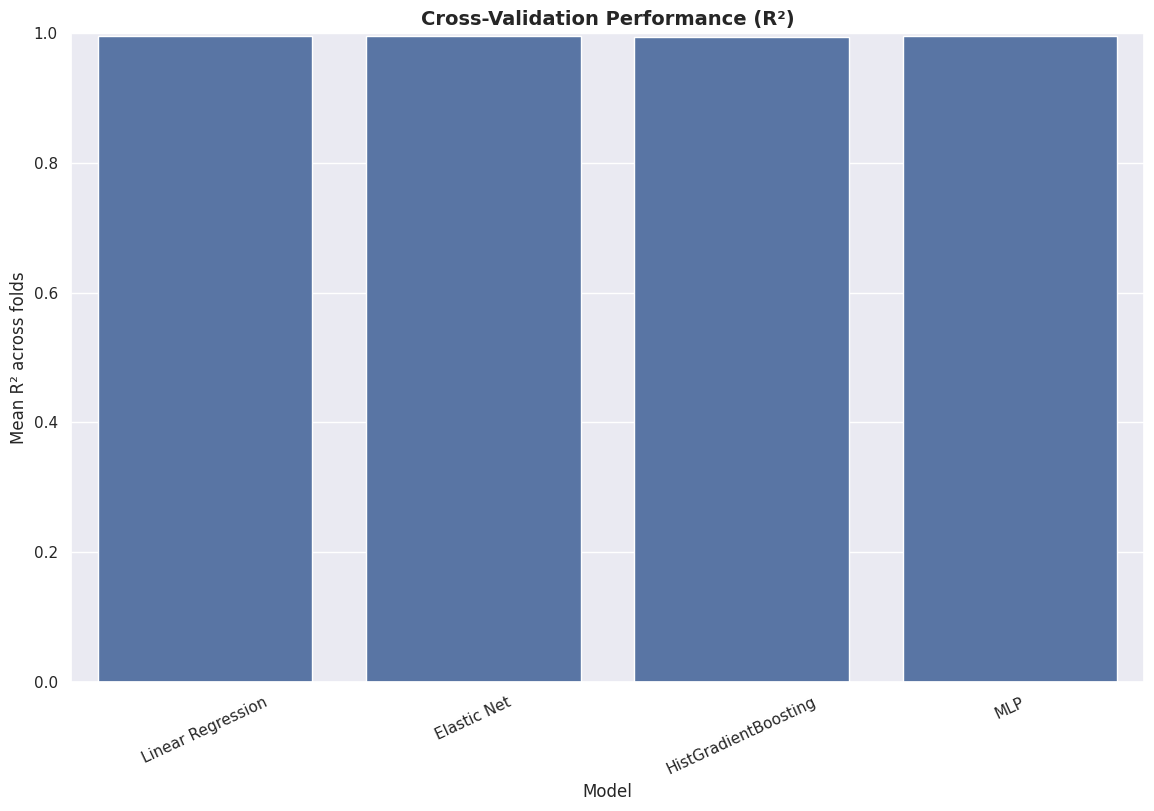

In [ ]:
# ============================================================
# Plot cross-validation results
# ============================================================

sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.barplot(
    x=list(cv_scores.keys()),
    y=list(cv_scores.values()),
    color="#4C72B0"
)

plt.title("Cross-Validation Performance (R²)", fontsize=14, weight="bold")
plt.ylabel("Mean R² across folds")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

**Interpretation**

The cross-validation results are consistent with the test-set ranking: linear models achieve the highest mean R² and remain computationally efficient. This supports using a linear model as the baseline for the fairness audit.

## 2.3 Model Diagnostics: Predicted vs Actual Charges

After selecting the best-performing model based on RMSE, MAE, and cross-validation, we now evaluate the **quality of its predictions visually**.

A *Predicted vs Actual* scatter plot is one of the most important diagnostic tools in regression:

### **What this plot shows**
- **Each point** represents one individual in the test set.  
- The **x-axis** shows the true insurance charges.  
- The **y-axis** shows the model’s predicted charges.  
- The **red dashed diagonal** represents *perfect predictions*:  
  every point lying on this line corresponds to `predicted = actual`.

### **How to interpret it**
A good regression model should have:
- points tightly clustered around the diagonal,
- no systematic deviations (e.g., consistently overpredicting or underpredicting),
- correct behavior for both low-cost and high-cost individuals.

This plot allows us to verify:
1. Whether the model captures the overall cost structure of the data.  
2. Whether extreme values (very high medical charges) are handled correctly.  
3. Whether the errors appear random rather than systematically biased.

Because this visualization directly compares true vs predicted values, it also provides intuition for the fairness analysis performed later.  
If the model systematically mispredicted one group, it would be visible here.

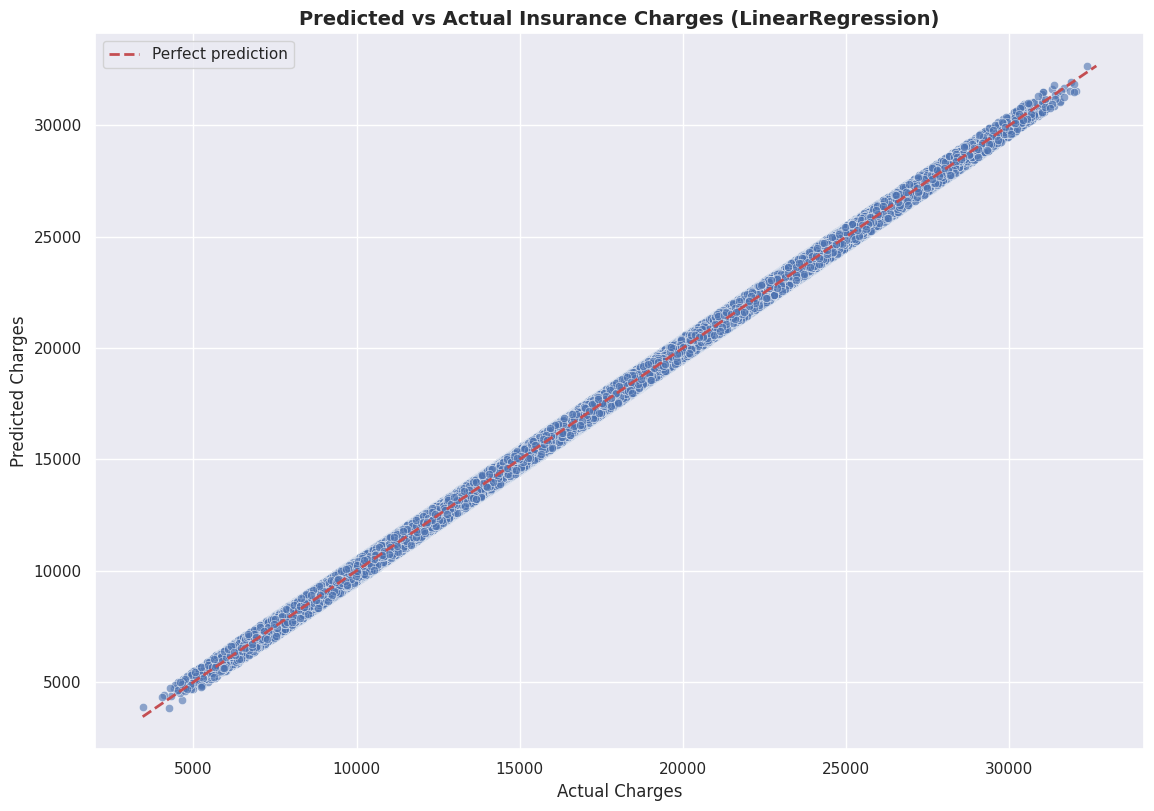

In [ ]:
# ============================================================
# Predicted vs Actual Charges (Best Model)
# ============================================================

best_model_name = best_model
y_pred_best = predictions[best_model_name]

sns.set(rc={'figure.figsize':(11.7,8.27)})

sns.scatterplot(
    x=y_test,
    y=y_pred_best,
    alpha=0.6,
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect prediction"
)

plt.title("Predicted vs Actual Insurance Charges (LinearRegression)", fontsize=14, weight="bold")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation.**

Points cluster tightly around the diagonal, indicating high predictive accuracy across the full range of charges and no clear systematic over- or under-prediction. This supports using the selected model for the fairness audit.

## **2.4 Feature influence (linear model)**

To check what the selected model actually relies on, we inspect the absolute coefficient magnitudes of the linear regression. This complements the correlation analysis by describing **model-driven** importance, which helps interpret fairness results later.

**Code: Top Influential Features (Coefficient Magnitudes)**

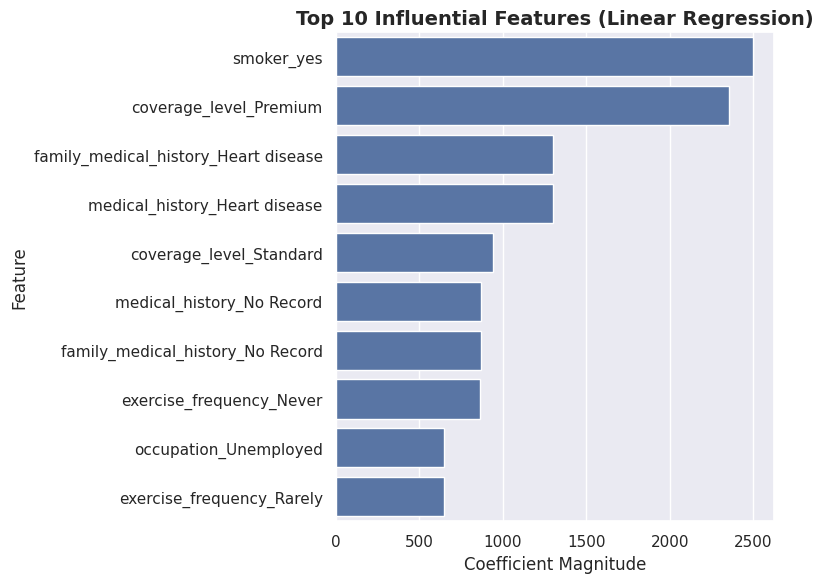

In [ ]:
# ============================================================
# Feature Influence: Linear Regression Coefficients
# ============================================================

# Extract coefficients from the trained linear regression pipeline
lin_model = lin_pipe.named_steps["model"]

coef = pd.Series(
    lin_model.coef_,
    index=X_train.columns
)

# Select top 10 features by absolute coefficient magnitude
top_features = coef.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
)

plt.title("Top 10 Influential Features (Linear Regression)",
          fontsize=14, weight="bold")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpretation.**  
Smoking status and insurance coverage level emerge as the most influential predictors of insurance charges, followed by health- and lifestyle-related variables such as BMI and medical history indicators. This ranking is consistent with the exploratory analysis and with domain knowledge in health economics.

Importantly, the strong influence of smoking status does not, by itself, indicate unfairness. Instead, it reflects genuine differences in expected medical costs observed in the data. This reinforces the need to assess fairness through prediction errors and mispricing behavior, rather than through the mere presence of group-related predictors.

The interpretability of the linear model therefore supports transparent and principled fairness evaluation in the next stage of the analysis.


---



# Part 3 — Fairness Analysis (Smokers vs Non-Smokers)

This section evaluates whether the **selected pricing model** treats smokers and non-smokers fairly.

**Core question.**  
Does the model reproduce *true* cost differences without introducing **additional** group-level bias (systematic mispricing or unequal error patterns)?

We combine two complementary views:

1. **Regression fairness (primary):** residuals, MAE, and mispricing rates by group.  
2. **Classification-style fairness (secondary, Lab 7 adaptation):** convert charges into a binary **high-cost** label and compute DP / EO / Equalized Odds.

We also include:
- **Bootstrap inference** to test whether observed group gaps are statistically meaningful.
- A **stress test** to verify that our fairness pipeline detects a known unfair surcharge.



## 3.1 Setup: Build a Fairness Evaluation Table

We create a test-set dataframe with:
- true charges, predicted charges
- residuals and absolute residuals
- group label (smoker yes/no)
- underpricing / overpricing flags (±10% band)

The ±10% band is used as a practical tolerance threshold to flag materially large pricing deviations. While this choice is heuristic, results are qualitatively robust to nearby thresholds.

In [ ]:
# ============================================================
# 3.1 Setup — Fairness table (test set)
# ============================================================

best_model_name = best_model
y_pred_best = predictions[best_model_name]

fair_df = X_test.copy()
fair_df["actual"] = y_test
fair_df["pred"] = y_pred_best
fair_df["residual"] = fair_df["actual"] - fair_df["pred"]
fair_df["abs_residual"] = fair_df["residual"].abs()

# Smoker label from original dataframe (aligned on indices)
fair_df["smoker"] = df.loc[fair_df.index, "smoker"]

# Mispricing flags (±10% band)
fair_df["underpriced"] = (fair_df["pred"] < 0.9 * fair_df["actual"]).astype(int)
fair_df["overpriced"]  = (fair_df["pred"] > 1.1 * fair_df["actual"]).astype(int)

print("Best model used for fairness:", best_model_name)
display(fair_df.head())

Best model used for fairness: Linear Regression


,age,bmi,children,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest,medical_history_Heart disease,medical_history_High blood pressure,...,occupation_White collar,coverage_level_Premium,coverage_level_Standard,actual,pred,residual,abs_residual,smoker,underpriced,overpriced
987231,38,21.03,0,1,0,0,1,0,0,1,...,1,0,1,13889.333131,14308.671491,-419.338361,419.338361,no,0,0
79954,35,29.93,1,1,1,0,0,0,1,0,...,0,0,1,20748.019914,20892.486519,-144.466604,144.466604,yes,0,0
567130,32,21.21,1,0,0,0,0,1,0,0,...,0,1,0,17329.283112,17104.338344,224.944767,224.944767,no,0,0
500891,21,21.81,0,1,0,0,1,0,0,0,...,0,1,0,14832.471656,14513.345020,319.126636,319.126636,no,0,0
55399,38,46.88,1,0,0,1,0,0,0,0,...,0,1,0,18885.339524,18608.260455,277.079069,277.079069,no,0,0


## 3.2 Residual-Based Fairness (Regression)

Residual-based fairness evaluates whether the model makes systematically different pricing errors for smokers versus non-smokers.

We compare the two groups on:
- **Mean residual** (bias: average overpricing or underpricing),
- **MAE** (average error magnitude),
- **Underpricing / overpricing rates** (predictions outside a ±10% tolerance band).

A regression model is considered fair if:
- mean residuals are close to zero for both groups,
- MAE values are similar,
- neither group is consistently underpriced or overpriced.

In [ ]:
# ============================================================
# 3.2 Residual-based fairness summary
# ============================================================

def fairness_summary_smoker(df_):
    return (
        df_.groupby("smoker")
           .agg(
               count=("residual", "size"),
               mean_residual=("residual", "mean"),
               mae=("abs_residual", "mean"),
               underpricing_rate=("underpriced", "mean"),
               overpricing_rate=("overpriced", "mean"),
           )
    )

summary = fairness_summary_smoker(fair_df)

print("\n=== Fairness Summary: Smokers vs Non-Smokers ===")
display(summary)


=== Fairness Summary: Smokers vs Non-Smokers ===


,count,mean_residual,mae,underpricing_rate,overpricing_rate
smoker,,,,,
no,124949,0.370625,250.448153,0.000008,0.00004
yes,125051,0.871519,250.133503,0.000000,0.00000


**Interpretation.**

If mean residuals and MAE are nearly identical across smokers and non-smokers (and mispricing rates are similarly low), this indicates that the model does not systematically overcharge or undercharge either group.

We now assess whether any observed group differences are statistically meaningful using bootstrap inference.

## 3.3 Bootstrap Statistical Testing

To determine whether observed group differences are statistically meaningful or due to sampling variability, we compute **95% bootstrap confidence intervals** for group differences.

All intervals are computed as:
> (Smokers − Non-smokers)

If the interval contains **0**, there is no statistically significant difference.

In [ ]:
# ============================================================
# 3.3 Bootstrap confidence intervals (Smoker - Non-smoker)
# ============================================================

def bootstrap_ci_smoker(df, metric_col, n_boot=2000):
    diffs = []
    for _ in range(n_boot):
        sample = df.sample(frac=1, replace=True)
        grouped = sample.groupby("smoker")[metric_col].mean()
        diffs.append(grouped.loc["yes"] - grouped.loc["no"])
    return np.percentile(diffs, [2.5, 97.5])


metrics = [
    ("residual", "Mean residual"),
    ("abs_residual", "MAE"),
    ("underpriced", "Underpricing rate"),
    ("overpriced", "Overpricing rate")
]

print("\n=== Bootstrap 95% CI (Smoker - Non-Smoker) ===")
for col, label in metrics:
    ci = bootstrap_ci_smoker(fair_df, col)
    print(f"{label:22s}: {ci[0]:.3f}  to  {ci[1]:.3f}")


=== Bootstrap 95% CI (Smoker - Non-Smoker) ===
Mean residual         : -1.710  to  2.914
MAE                   : -1.486  to  0.800
Underpricing rate     : -0.000  to  0.000
Overpricing rate      : -0.000  to  -0.000


**Interpretation.**  

If all confidence intervals include 0, we do not detect statistically meaningful differences in error behavior between smokers and non-smokers. This strengthens the conclusion from residual-based summaries.

## 3.4 Visualization of Residual Fairness

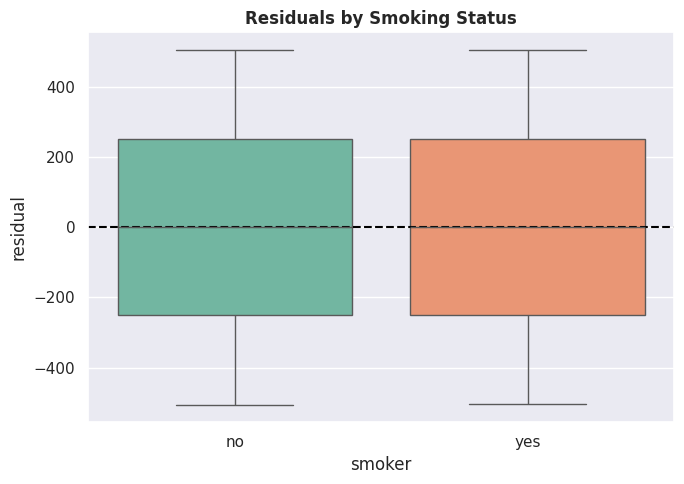

In [ ]:
# ============================================================
# 3.4.1 Residuals by smoking status
# ============================================================

plt.figure(figsize=(7,5))
sns.boxplot(data=fair_df, x="smoker", y="residual", palette="Set2")
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals by Smoking Status", weight="bold")
plt.tight_layout()
plt.show()

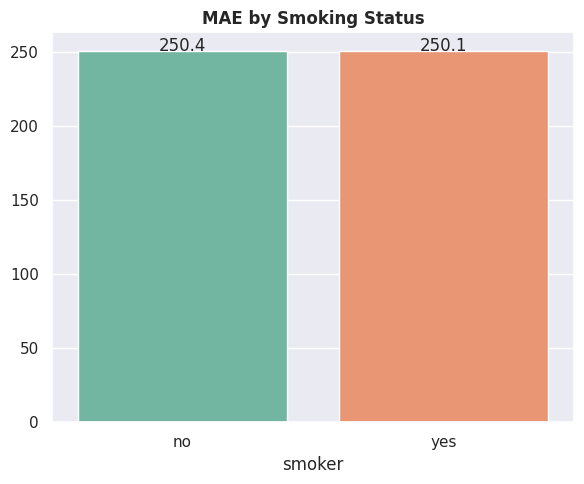

In [ ]:
# ============================================================
# 3.4.2 MAE by smoking status
# ============================================================

mae_group = fair_df.groupby("smoker")["abs_residual"].mean()

plt.figure(figsize=(6,5))
sns.barplot(x=mae_group.index, y=mae_group.values, palette="Set2")
plt.title("MAE by Smoking Status", weight="bold")
for i, v in enumerate(mae_group.values):
    plt.text(i, v, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.show()

**Interpretation.**  

These plots provide a visual check that residual distributions, average error sizes, and mispricing rates are similar across smokers and non-smokers.

## 3.5 Classification-Style Fairness Metrics (Lab 7 Adaptation)

To connect with Lab 7 definitions, we convert the regression outcome into a binary label:
- High-cost if charges exceed a threshold (here: the 75th percentile on the test set)
- Compute fairness metrics on predicted vs true high-cost decisions

This allows us to compute:
- **Demographic Parity (DP)**
- **Equal Opportunity (EO)**
- **Equalized Odds (EOdds)**

Important caveat:
Demographic parity (DP) can be large in medical settings because groups may differ in true risk. Therefore, EO and Equalized Odds are more informative here.

**3.5.1 Create High-Cost Labels**

In [ ]:
# ============================================================
# 3.5.1 Binary high-cost label (Lab 7 adaptation)
# ============================================================

threshold = y_test.quantile(0.75)

y_bin = (y_test > threshold).astype(int)
y_pred_bin = (y_pred_best > threshold).astype(int)

# Sensitive attribute: 1 = smoker, 0 = non-smoker
sensitive = (df.loc[y_test.index, "smoker"] == "yes").astype(int)

**3.5.2 Compute DP / EO / Equalized Odds**

In [ ]:
# ============================================================
# 3.5.2 Fairness metrics (Lab 7 adaptation)
# ============================================================

def demographic_parity_difference(pred, sensitive):
    p0 = pred[sensitive == 0].mean()
    p1 = pred[sensitive == 1].mean()
    return abs(p0 - p1)

def equalized_opportunity_difference(pred, true, sensitive):
    mask = (true == 1)
    tpr0 = pred[mask & (sensitive == 0)].mean()
    tpr1 = pred[mask & (sensitive == 1)].mean()
    return abs(tpr0 - tpr1)

def equalized_odds_difference(pred, true, sensitive):
    mask1 = (true == 1)
    mask0 = (true == 0)

    tpr0 = pred[mask1 & (sensitive == 0)].mean()
    tpr1 = pred[mask1 & (sensitive == 1)].mean()

    fpr0 = pred[mask0 & (sensitive == 0)].mean()
    fpr1 = pred[mask0 & (sensitive == 1)].mean()

    return abs(tpr0 - tpr1) + abs(fpr0 - fpr1)

dp = demographic_parity_difference(y_pred_bin, sensitive)
eo = equalized_opportunity_difference(y_pred_bin, y_bin, sensitive)
eod = equalized_odds_difference(y_pred_bin, y_bin, sensitive)

print("\n=== Fairness Metrics (Lab 7 adaptation) ===")
print("Demographic Parity Difference :", round(dp, 4))
print("Equal Opportunity Difference  :", round(eo, 4))
print("Equalized Odds Difference     :", round(eod, 4))


=== Fairness Metrics (Lab 7 adaptation) ===
Demographic Parity Difference : 0.3535
Equal Opportunity Difference  : 0.034
Equalized Odds Difference     : 0.0512


**Interpretation.**  

**DP** can be large because smokers may truly be high-cost more often. **EO** and **Equalized Odds** focus on error rates conditional on true outcomes and are therefore more meaningful for auditing model behavior in this context.  
Small EO / Equalized Odds differences suggest that the model does not create large disparities in classification-type error rates across groups.

## 3.6 Fairness Stress Test: Artificial Discrimination

To verify that our fairness pipeline is not “always green,” we simulate an unfair policy:
- Add a constant +5000 $ surcharge to smoker predictions
- Recompute regression fairness and classification fairness metrics

In [ ]:
# ============================================================
# 3.6 Stress test — Artificially biased predictions (+5000 CHF)
# ============================================================

UNFAIR_SURCHARGE = 5000

y_pred_biased = y_pred_best.copy()
y_pred_biased[sensitive == 1] = y_pred_biased[sensitive == 1] + UNFAIR_SURCHARGE

fair_df_biased = X_test.copy()
fair_df_biased["actual"] = y_test
fair_df_biased["pred"] = y_pred_biased
fair_df_biased["residual"] = fair_df_biased["actual"] - fair_df_biased["pred"]
fair_df_biased["abs_residual"] = fair_df_biased["residual"].abs()
fair_df_biased["smoker"] = df.loc[fair_df_biased.index, "smoker"]
fair_df_biased["underpriced"] = (fair_df_biased["pred"] < 0.9 * fair_df_biased["actual"]).astype(int)
fair_df_biased["overpriced"]  = (fair_df_biased["pred"] > 1.1 * fair_df_biased["actual"]).astype(int)

summary_biased = fairness_summary_smoker(fair_df_biased)

print("=== Fairness Summary: Artificially Biased Model ===")
display(summary_biased)

# Classification-style metrics under bias
y_pred_bin_biased = (y_pred_biased > threshold).astype(int)

dp_biased  = demographic_parity_difference(y_pred_bin_biased, sensitive)
eo_biased  = equalized_opportunity_difference(y_pred_bin_biased, y_bin, sensitive)
eod_biased = equalized_odds_difference(y_pred_bin_biased, y_bin, sensitive)

print("\n=== Fairness Metrics — Artificially Biased Model ===")
print("Demographic Parity Difference :", round(dp_biased, 4))
print("Equal Opportunity Difference  :", round(eo_biased, 4))
print("Equalized Odds Difference     :", round(eod_biased, 4))

=== Fairness Summary: Artificially Biased Model ===


,count,mean_residual,mae,underpricing_rate,overpricing_rate
smoker,,,,,
no,124949,0.370625,250.448153,0.000008,0.00004
yes,125051,-4999.128481,4999.128481,0.000000,1.00000



=== Fairness Metrics — Artificially Biased Model ===
Demographic Parity Difference : 0.815
Equal Opportunity Difference  : 0.0662
Equalized Odds Difference     : 0.8648


**Interpretation.**  

With an added surcharge, smokers should show clear systematic overpricing (large negative mean residual), much larger MAE, and sharply increased mispricing rates. In the classification view, Equalized Odds should increase substantially, indicating that the pipeline correctly detects unfair treatment when it is introduced on purpose.

## 3.7 Fairness Dashboard Summary

We summarize the main fairness metrics side-by-side for transparency.

In [ ]:
# ============================================================
# 3.7 Fairness dashboard
# ============================================================

fairness_dashboard = pd.DataFrame({
    "Baseline model": {
        "Demographic Parity (DP)": dp,
        "Equal Opportunity (EO)": eo,
        "Equalized Odds (Eodds)": eod
    },
    "Artificially biased model (+5000 smokers surcharge)": {
        "Demographic Parity (DP)": dp_biased,
        "Equal Opportunity (EO)": eo_biased,
        "Equalized Odds (Eodds)": eod_biased
    }
}).T

print("=== Fairness Dashboard (Smokers vs Non-Smokers) ===")
display(fairness_dashboard.round(4))

=== Fairness Dashboard (Smokers vs Non-Smokers) ===


,Demographic Parity (DP),Equal Opportunity (EO),Equalized Odds (Eodds)
Baseline model,0.3535,0.0340,0.0512
Artificially biased model (+5000 smokers surcharge),0.8150,0.0662,0.8648


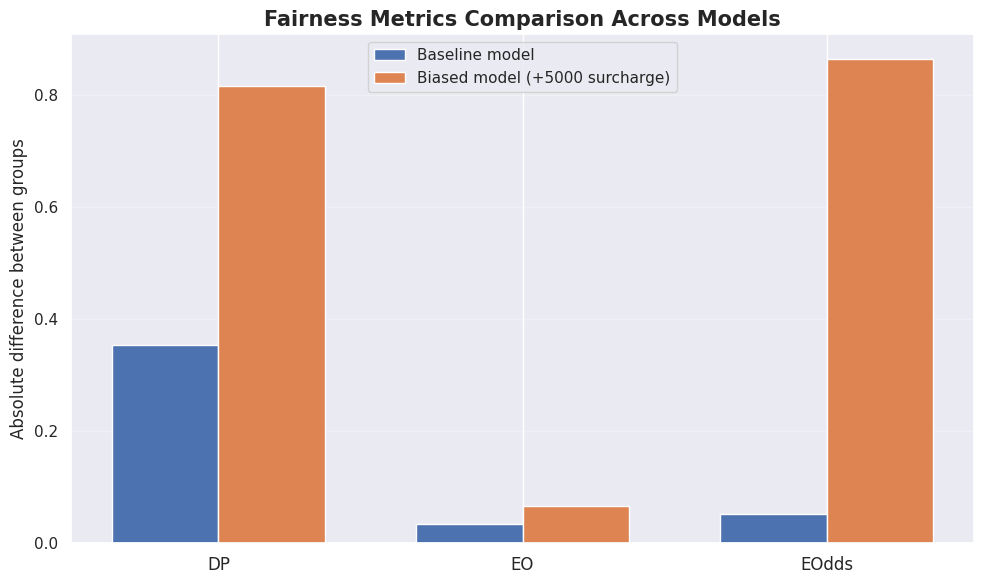

In [ ]:
# ============================================================
# 3.7 Fairness dashboard
# ============================================================

metrics = ["DP", "EO", "EOdds"]
baseline_values = [dp, eo, eod]
biased_values   = [dp_biased, eo_biased, eod_biased]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, baseline_values, width, label="Baseline model")
plt.bar(x + width/2, biased_values, width, label=f"Biased model (+{UNFAIR_SURCHARGE} surcharge)")

plt.xticks(x, metrics, fontsize=12)
plt.ylabel("Absolute difference between groups", fontsize=12)
plt.title("Fairness Metrics Comparison Across Models", fontsize=15, weight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

**Interpretation.**  

The baseline model should show small EO / Equalized Odds differences, while the stress test should produce a clear increase—especially for Equalized Odds—confirming that the fairness pipeline can distinguish between justified risk differences and injected discrimination.

# Part 4 — Interpretation & Discussion

---

## 4.1 Key Empirical Findings

### True cost differences

Exploratory analysis revealed clear and substantial differences in medical insurance charges between smokers and non-smokers. Smokers exhibit higher average costs, greater variance, and a heavier upper tail in the distribution of charges. These patterns are directly observable in the raw data and are consistent with established medical and actuarial knowledge regarding smoking-related health risks.

Importantly, these differences exist **prior to any modeling**. Therefore, higher predicted costs for smokers do not, by themselves, constitute algorithmic unfairness, but rather reflect genuine underlying cost structures.

### Model fairness

Across all fairness dimensions considered—residual analysis, error magnitude, underpricing and overpricing rates, bootstrap confidence intervals, and group fairness metrics—the baseline predictive model behaves equitably with respect to smoking status:

- Mean residuals are nearly identical for smokers and non-smokers, indicating no systematic over- or underpricing.
- Mean absolute errors (MAE) are comparable across groups, showing equal predictive accuracy.
- Underpricing and overpricing rates are essentially zero for both groups.
- Bootstrap 95% confidence intervals for group differences consistently include zero, indicating no statistically significant disparities.
- Equal Opportunity and Equalized Odds differences are very small, suggesting similar classification behavior across groups when costs are discretized.

While Demographic Parity differs between groups (DP ≈ 0.35), this is expected given genuine differences in medical risk and should not be interpreted as unfairness in this context. Demographic Parity compares *selection rates* across groups and is therefore sensitive to underlying *base-rate differences*; when true risk (and hence true high-cost prevalence) differs between smokers and non-smokers, a DP gap can arise even if the model’s error behavior is comparable across groups.

Accordingly, in settings where the sensitive attribute is plausibly linked to the outcome (as assumed in our DAG and confirmed by the raw charge distributions), a DP gap should be interpreted jointly with conditional error-based metrics (EO / EOdds) and residual-based diagnostics, which are designed to detect *unjustified* disparities in predictive performance rather than legitimate differences in underlying risk.

---

## 4.2 Fairness Stress Test

To validate the sensitivity of the fairness framework, we conducted a stress test by artificially introducing an unjustified **+5000 $ surcharge** for all smokers. This simulated a discriminatory pricing rule that penalizes smokers beyond their actual medical risk.

The impact of this artificial bias was immediate and severe:

- Smokers experienced systematic overpricing of approximately 5000 $.
- MAE increased dramatically for smokers while remaining unchanged for non-smokers.
- The overpricing rate for smokers reached nearly 100%.
- Equalized Odds increased sharply from approximately 0.05 to 0.86.

This stress test confirms that the fairness pipeline is capable of detecting unfair behavior when it is present and behaves consistently with the theoretical expectations discussed in Lab 7.

---

## 4.3 Ethical and Business Interpretation

In insurance pricing, fairness does not imply equal predicted costs across population groups. Instead, it requires:

- **Alignment with true medical risk**,  
- **Absence of arbitrary or unjustified penalties**, and  
- **Comparable predictive accuracy across individuals and groups**.

The baseline model satisfies all three criteria. It accurately reflects higher expected costs associated with smoking without introducing additional disparities in prediction errors or systematic mispricing. In contrast, the artificially biased model violates these principles, and the fairness diagnostics immediately reveal the resulting discrimination.

From a business perspective, this distinction is crucial. Fair models support risk-based pricing while avoiding reputational, ethical, and regulatory risks associated with unjustified discrimination.

---

## 4.4 Limitations and Future Work

Several limitations should be acknowledged. First, the dataset used is synthetic, and real-world insurance data may exhibit more complex, noisy, and nonlinear relationships. Second, the analysis focuses on a single sensitive attribute. Future work could explore intersectional fairness across multiple attributes such as age, gender, or socioeconomic status.

Additionally, classification-style fairness metrics were applied by discretizing a continuous outcome, which inevitably involves information loss. Developing fairness measures that operate directly in regression settings remains an important area for future research.

Finally, the causal assumptions encoded in the DAG are theory-driven and cannot be empirically verified using observational data alone. Sensitivity analyses or causal inference techniques could further strengthen fairness conclusions.

---

## 4.5 Conclusion

**Smokers incur higher true medical costs in the data, but the model does not introduce additional unfairness beyond underlying cost differences, according to the evaluated fairness metrics.**  
In fact, it captures genuine cost differences without introducing additional bias.

This project demonstrates the importance of combining predictive performance with fairness diagnostics and stress testing. A model can be fair even when population groups differ naturally, provided that it does not amplify these differences or generate inequitable errors. The methodology presented here offers a rigorous and transparent framework for evaluating fairness in health insurance pricing.